<a href="https://colab.research.google.com/github/bhaktii856/AQI-prediction/blob/main/aqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving peeragadi.csv to peeragadi.csv


In [ ]:
df = pd.read_csv("peeragadi.csv")

In [ ]:
df.head()

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,u10,v10,d2m,t2m,sp,AOD,S5P_CO,S5P_NO2,S5P_O3,S5P_SO2
0,2025-01-01,207.96,327.35,76.34,70.21,99.41,74.43,12.16,2.13,4.17,...,1.265732,-0.155411,8.870789,10.180084,992.8095,1116.000000,0.046674,0.000175,0.116190,0.000128
1,2025-01-02,208.17,319.46,66.57,67.96,85.17,83.13,7.86,2.16,4.55,...,2.869873,0.250031,8.540344,9.050598,990.9611,1163.333333,0.045843,0.000218,0.115874,0.000421
2,2025-01-03,470.81,675.09,163.89,117.78,176.84,117.57,23.07,3.04,5.39,...,1.659882,-0.079544,9.332794,9.705231,991.6883,1210.666667,0.045012,0.000262,0.115558,0.000715
3,2025-01-04,358.85,454.33,94.80,82.99,130.12,118.83,12.07,2.78,7.14,...,-0.984314,-1.458313,8.655121,8.741760,989.3943,1258.000000,0.044181,0.000305,0.115242,0.001008
4,2025-01-05,190.02,269.27,36.41,54.28,58.45,58.02,9.62,1.73,5.16,...,-2.084015,0.842651,9.639191,9.638184,989.3683,644.000000,0.042989,0.000202,0.119795,-0.000211


In [ ]:
df.shape

(15695, 37)

In [ ]:
df.isnull().sum()

,0
Timestamp,0
PM2.5 (µg/m³),0
PM10 (µg/m³),0
NO (µg/m³),0
NO2 (µg/m³),0
NOx (ppb),0
NH3 (µg/m³),0
SO2 (µg/m³),0
CO (mg/m³),0
Ozone (µg/m³),0


In [ ]:
print(df.columns.tolist())

['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'Station', 'Date', 'Month', 'Day', 'latitude_x', 'longitude_x', 'latitude_y', 'longitude_y', 'tp', 'bld', 'u10', 'v10', 'd2m', 't2m', 'sp', 'AOD', 'S5P_CO', 'S5P_NO2', 'S5P_O3', 'S5P_SO2']


In [ ]:
breakpoints = {
    "PM25": [
        (0,30,0,50),
        (31,60,51,100),
        (61,90,101,200),
        (91,120,201,300),
        (121,250,301,400),
        (251,1000,401,500)
    ],

    "PM10": [
        (0,50,0,50),
        (51,100,51,100),
        (101,250,101,200),
        (251,350,201,300),
        (351,430,301,400),
        (431,2000,401,500)
    ],

    "NO2": [
        (0,40,0,50),
        (41,80,51,100),
        (81,180,101,200),
        (181,280,201,300),
        (281,400,301,400),
        (401,1000,401,500)
    ],

    "SO2": [
        (0,40,0,50),
        (41,80,51,100),
        (81,380,101,200),
        (381,800,201,300),
        (801,1600,301,400),
        (1601,5000,401,500)
    ],

    "CO": [
        (0,1,0,50),
        (1.1,2,51,100),
        (2.1,10,101,200),
        (10.1,17,201,300),
        (17.1,34,301,400),
        (34.1,100,401,500)
    ],

    "O3": [
        (0,50,0,50),
        (51,100,51,100),
        (101,168,101,200),
        (169,208,201,300),
        (209,748,301,400),
        (749,2000,401,500)
    ]
}

In [ ]:
import numpy as np

def sub_index(c, bp):

    if np.isnan(c):
        return np.nan

    for Clow, Chigh, Ilow, Ihigh in bp:

        if Clow <= c <= Chigh:

            return ((Ihigh-Ilow)/(Chigh-Clow))*(c-Clow)+Ilow

    return 500

In [ ]:
df["PM25_sub"] = df["PM2.5 (µg/m³)"].apply(lambda x: sub_index(x, breakpoints["PM25"]))

df["PM10_sub"] = df["PM10 (µg/m³)"].apply(lambda x: sub_index(x, breakpoints["PM10"]))

df["NO2_sub"] = df["NO2 (µg/m³)"].apply(lambda x: sub_index(x, breakpoints["NO2"]))

df["SO2_sub"] = df["SO2 (µg/m³)"].apply(lambda x: sub_index(x, breakpoints["SO2"]))

df["CO_sub"] = df["CO (mg/m³)"].apply(lambda x: sub_index(x, breakpoints["CO"]))

df["O3_sub"] = df["Ozone (µg/m³)"].apply(lambda x: sub_index(x, breakpoints["O3"]))

In [ ]:
df["AQI"] = df[
    [
        "PM25_sub",
        "PM10_sub",
        "NO2_sub",
        "SO2_sub",
        "CO_sub",
        "O3_sub"
    ]
].max(axis=1)

In [ ]:
df[[
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO2 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)",
    "AQI"
]].head(10)

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),AQI
0,207.96,327.35,70.21,12.16,2.13,4.17,367.736744
1,208.17,319.46,67.96,7.86,2.16,4.55,367.897907
2,470.81,675.09,117.78,23.07,3.04,5.39,430.053658
3,358.85,454.33,82.99,12.07,2.78,7.14,415.255207
4,190.02,269.27,54.28,9.62,1.73,5.16,353.968837
5,226.06,325.59,68.10,10.17,2.30,4.01,381.627442
6,211.79,336.69,69.54,19.46,1.74,4.03,370.676047
7,205.46,375.40,79.28,17.23,2.37,7.32,365.818140
8,436.83,636.49,69.75,25.48,4.57,7.48,425.562310
9,353.12,467.82,49.26,31.18,3.14,6.84,414.497837


In [ ]:
drop_cols = [
    "PM2.5 (µg/m³)",
    "PM10 (µg/m³)",
    "NO (µg/m³)",
    "NO2 (µg/m³)",
    "NOx (ppb)",
    "NH3 (µg/m³)",
    "SO2 (µg/m³)",
    "CO (mg/m³)",
    "Ozone (µg/m³)"
]

df = df.drop(columns=drop_cols)

In [ ]:
df = df.drop(columns=[
    "PM25_sub",
    "PM10_sub",
    "NO2_sub",
    "SO2_sub",
    "CO_sub",
    "O3_sub"
])

In [ ]:
df = df.drop(columns=["Timestamp"])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Station"] = le.fit_transform(df["Station"])

In [ ]:
print(df.columns)

Index(['AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'TOT-RF (mm)',
       'SR (W/mt2)', 'BP (mmHg)', 'Station', 'Date', 'Month', 'Day',
       'latitude_x', 'longitude_x', 'latitude_y', 'longitude_y', 'tp', 'bld',
       'u10', 'v10', 'd2m', 't2m', 'sp', 'AOD', 'S5P_CO', 'S5P_NO2', 'S5P_O3',
       'S5P_SO2', 'AQI'],
      dtype='object')


In [ ]:
print((df["latitude_x"] == df["latitude_y"]).all())

print((df["longitude_x"] == df["longitude_y"]).all())

False
False


In [ ]:
different = df[
    (df["latitude_x"] != df["latitude_y"]) |
    (df["longitude_x"] != df["longitude_y"])
]

print("Number of different rows:", len(different))

different[[
    "Station",
    "latitude_x",
    "longitude_x",
    "latitude_y",
    "longitude_y"
]].head(10)

Number of different rows: 15695


,Station,latitude_x,longitude_x,latitude_y,longitude_y
0,0,28.647622,77.315809,28.75,77.25
1,0,28.647622,77.315809,28.75,77.25
2,0,28.647622,77.315809,28.75,77.25
3,0,28.647622,77.315809,28.75,77.25
4,0,28.647622,77.315809,28.75,77.25
5,0,28.647622,77.315809,28.75,77.25
6,0,28.647622,77.315809,28.75,77.25
7,0,28.647622,77.315809,28.75,77.25
8,0,28.647622,77.315809,28.75,77.25
9,0,28.647622,77.315809,28.75,77.25


In [ ]:
X = df.drop(columns=["AQI"])

y = df["AQI"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (15695, 27)
Target Shape: (15695,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (12556, 27)
Testing set: (3139, 27)


In [ ]:
print(X.dtypes)

AT (°C)        float64
RH (%)         float64
WS (m/s)       float64
WD (deg)       float64
TOT-RF (mm)    float64
SR (W/mt2)     float64
BP (mmHg)      float64
Station          int64
Date            object
Month            int64
Day              int64
latitude_x     float64
longitude_x    float64
latitude_y     float64
longitude_y    float64
tp             float64
bld            float64
u10            float64
v10            float64
d2m            float64
t2m            float64
sp             float64
AOD            float64
S5P_CO         float64
S5P_NO2        float64
S5P_O3         float64
S5P_SO2        float64
dtype: object


In [ ]:
X = X.drop(columns=["Date"])

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from xgboost import XGBRegressor

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.4396395426366114


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 74.90570987334117


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 111.14754810750864


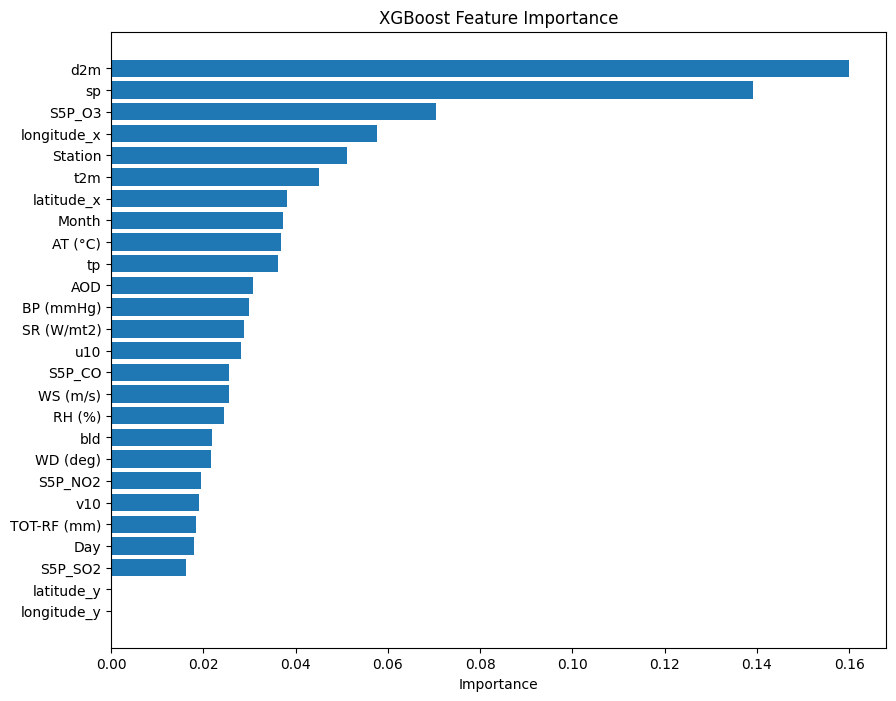

        Feature  Importance
18          d2m    0.159985
20           sp    0.139129
24       S5P_O3    0.070427
11  longitude_x    0.057733
7       Station    0.051063
19          t2m    0.045168
10   latitude_x    0.038230
8         Month    0.037289
0       AT (°C)    0.036767
14           tp    0.036201
21          AOD    0.030762
6     BP (mmHg)    0.029833
5    SR (W/mt2)    0.028770
16          u10    0.028174
22       S5P_CO    0.025652
2      WS (m/s)    0.025589
1        RH (%)    0.024523
15          bld    0.021770
3      WD (deg)    0.021724
23      S5P_NO2    0.019572
17          v10    0.018976
4   TOT-RF (mm)    0.018482
9           Day    0.017890
25      S5P_SO2    0.016291
12   latitude_y    0.000000
13  longitude_y    0.000000


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()

print(importance)

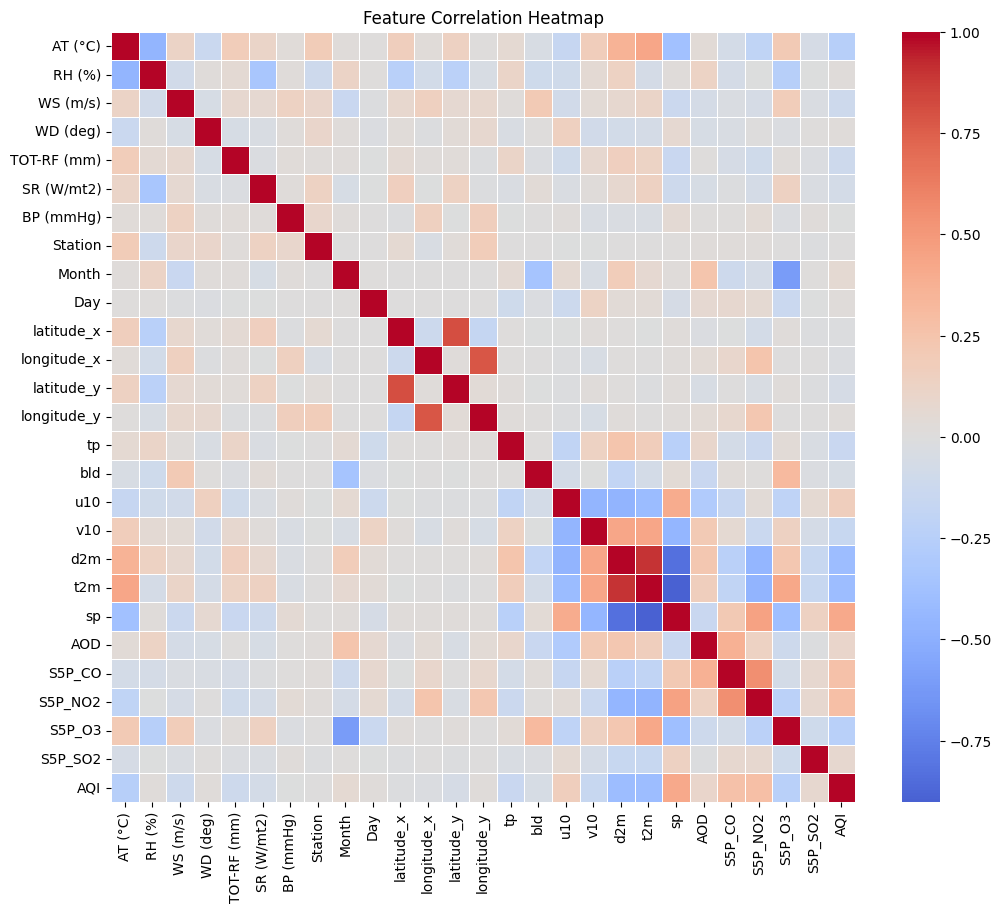

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
print(df["AQI"].describe())

count    15695.000000
mean       260.622212
std        148.507099
min         22.140000
25%        121.122248
50%        245.379310
75%        378.108910
max        500.000000
Name: AQI, dtype: float64


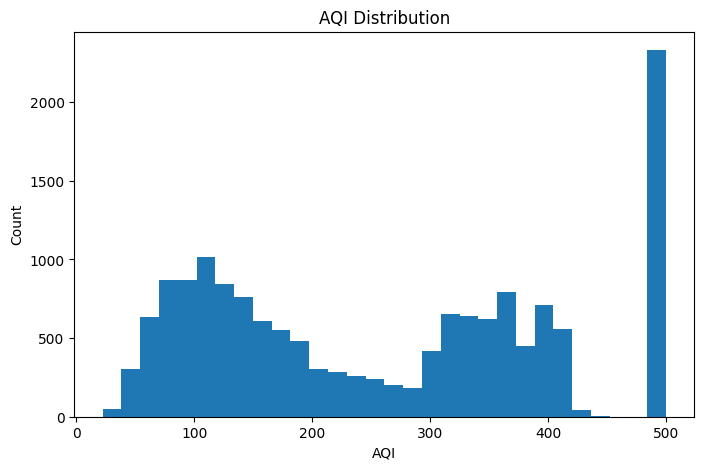

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["AQI"], bins=30)
plt.xlabel("AQI")
plt.ylabel("Count")
plt.title("AQI Distribution")
plt.show()

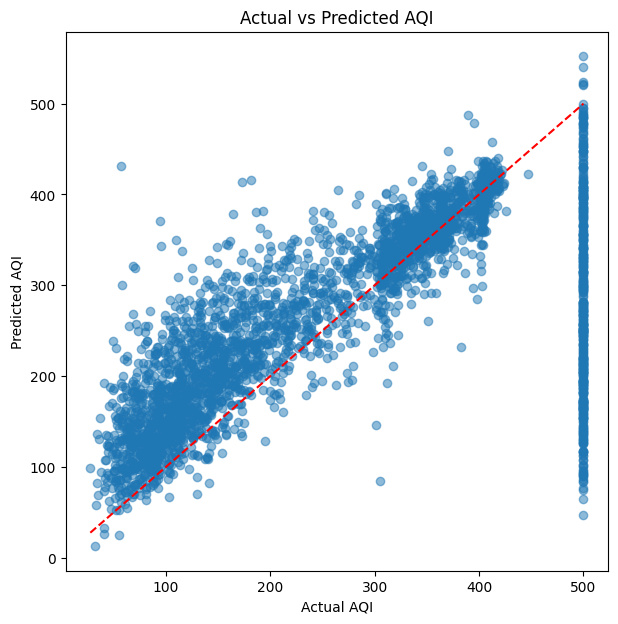

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

In [ ]:
print((df["AQI"] == 500).sum())

2332


In [ ]:
X = df[[
    "Month",
    "latitude_x",
    "longitude_x"
]]

y = df["AQI"]

In [ ]:
print(X.head())

print(X.shape)

   Month  latitude_x  longitude_x
0      1   28.647622    77.315809
1      1   28.647622    77.315809
2      1   28.647622    77.315809
3      1   28.647622    77.315809
4      1   28.647622    77.315809
(15695, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.3857848516117762
MAE : 80.42406220437707
RMSE : 115.18130468123826


In [ ]:
corr = df.corr(numeric_only=True)

print(corr["AQI"].sort_values(ascending=False))

AQI            1.000000
sp             0.414173
S5P_NO2        0.283899
S5P_CO         0.264811
u10            0.166476
AOD            0.098935
S5P_SO2        0.076189
Month          0.062601
RH (%)         0.026937
WD (deg)       0.024795
longitude_y    0.022864
Day            0.018902
Station        0.002109
BP (mmHg)     -0.005231
latitude_x    -0.011521
longitude_x   -0.018505
bld           -0.048500
latitude_y    -0.058805
SR (W/mt2)    -0.073190
WS (m/s)      -0.108769
TOT-RF (mm)   -0.110631
tp            -0.139805
v10           -0.151970
S5P_O3        -0.243893
AT (°C)       -0.254682
t2m           -0.404224
d2m           -0.407595
Name: AQI, dtype: float64


In [ ]:
X = df.drop(columns=[
    "AQI",
    "latitude_y",
    "longitude_y"
])

y = df["AQI"]

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    objective="reg:squarederror",
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.3780777756489203
MAE : 80.23391618990068
RMSE : 115.90169043469832


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

from sklearn.metrics import r2_score

print("R²:", r2_score(y_test, y_pred))


R²: 0.3781542981079906


In [ ]:
print("Stations:", df["Station"].nunique())
print("Dates:", df["Date"].nunique())
print("AOD:", df["AOD"].nunique())
print("S5P_NO2:", df["S5P_NO2"].nunique())
print("S5P_CO:", df["S5P_CO"].nunique())
print("S5P_SO2:", df["S5P_SO2"].nunique())
print("S5P_O3:", df["S5P_O3"].nunique())


Stations: 43
Dates: 365
AOD: 8175
S5P_NO2: 14865
S5P_CO: 14549
S5P_SO2: 14920
S5P_O3: 15011


In [ ]:
df[["Date","Station","S5P_NO2","S5P_CO","AOD"]].head(20)

,Date,Station,S5P_NO2,S5P_CO,AOD
0,2025-01-01,0,0.000175,0.046674,1116.000000
1,2025-01-02,0,0.000218,0.045843,1163.333333
2,2025-01-03,0,0.000262,0.045012,1210.666667
3,2025-01-04,0,0.000305,0.044181,1258.000000
4,2025-01-05,0,0.000202,0.042989,644.000000
5,2025-01-06,0,0.000174,0.044059,592.166667
6,2025-01-07,0,0.000146,0.045129,540.333333
7,2025-01-08,0,0.000118,0.046198,488.500000
8,2025-01-09,0,0.000511,0.057941,506.400000
9,2025-01-10,0,0.000190,0.044526,524.300000


In [ ]:
print(df["AOD"].describe())

count    15695.000000
mean       889.222364
std        493.660012
min         36.000000
25%        518.000000
50%        805.000000
75%       1141.311747
max       4519.000000
Name: AOD, dtype: float64


In [ ]:
print(df[["S5P_NO2","S5P_CO","S5P_SO2","S5P_O3"]].describe())

            S5P_NO2        S5P_CO       S5P_SO2        S5P_O3
count  15695.000000  15695.000000  15695.000000  15695.000000
mean       0.000107      0.041168      0.000098      0.126635
std        0.000061      0.005580      0.000514      0.006778
min        0.000015      0.023158     -0.000990      0.106151
25%        0.000067      0.037008     -0.000101      0.123152
50%        0.000094      0.040110      0.000039      0.126773
75%        0.000128      0.044639      0.000208      0.131028
max        0.000883      0.074825      0.011423      0.146175
